In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pqcd
import pickle

from cmcrameri import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy.stats import gaussian_kde
from pqcd.utils import (
    to_GeV_per_cubic_femtometre,
    to_nucleons_per_cubic_femtometre,
    GeV_per_cubic_femtometer_to_dyn_per_square_cm,
    nsat,
)
from plot_utils import (
    rcparams,
    x_pe,
    x_cn,
    xlim_pe,
    ylim_pe,
    xlim_cn,
    ylim_cn,
    prior_kwargs
)
plt.rcParams.update(rcparams)

In [2]:
collated_eos_gp2 = pd.read_csv(
    '../data/eos-draws-modified/gp2/eos-draws-modified-gp2.csv'
)

In [3]:
n0 = 10*nsat

In [4]:
l_gp2 = 0
number_gp2 = 10000

In [5]:
e_kde = []
p_kde = []

for i, n in enumerate(collated_eos_gp2.eos.iloc[l_gp2:l_gp2+number_gp2]):

    df = pd.read_csv(
        f'../data/eos-draws-modified/gp2/margagn/DRAWmod1000-{int(n)//1000:06}/eos-draw-{int(n):06}.csv'
    )

    pressure = to_GeV_per_cubic_femtometre(df.pressurec2)
    energy_density = to_GeV_per_cubic_femtometre(df.energy_densityc2)
    number_density = to_nucleons_per_cubic_femtometre(df.baryon_density)

    highlight_index = np.argmin((number_density - n0)**2)
    e_kde.append(energy_density[highlight_index])
    p_kde.append(pressure[highlight_index])

Plot our sample of unified GP EOS draws, and mark where they hit $10\,n_\mathrm{sat}$:

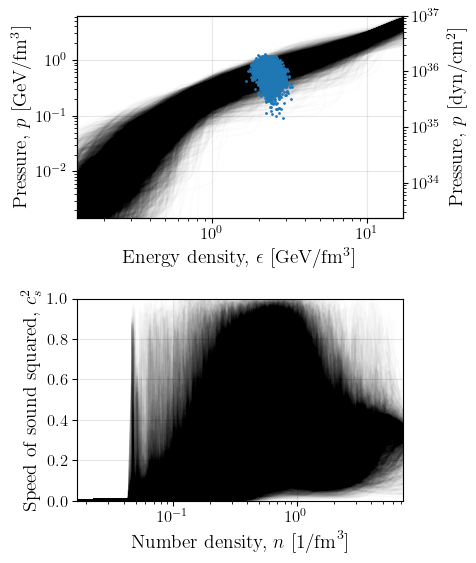

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(4.2, 6.3))
fig.subplots_adjust(hspace=0.4)

for ax in axs:
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3)

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')

# ---

for i, n in enumerate(collated_eos_gp2.eos.iloc[l_gp2:l_gp2+number_gp2]):

    df = pd.read_csv(
        f'../data/eos-draws-modified/gp2/margagn/DRAWmod1000-{int(n)//1000:06}/eos-draw-{int(n):06}.csv'
    )

    pressure = to_GeV_per_cubic_femtometre(df.pressurec2)
    energy_density = to_GeV_per_cubic_femtometre(df.energy_densityc2)
    number_density = to_nucleons_per_cubic_femtometre(df.baryon_density)
    speed_of_sound_squared = np.gradient(pressure, energy_density)

    axs[0].plot(
        energy_density,
        pressure,
        c='k',
        alpha=0.01,
        zorder=1
    )

    axs[0].plot(e_kde[i], p_kde[i], 'o', c='C0', markersize=1, zorder=1.1)

    axs[1].plot(
        number_density,
        speed_of_sound_squared,
        c='k',
        alpha=0.01
    )

# ---

axs[0].set_xlim(xlim_pe)
axs[0].set_ylim(ylim_pe)

axs[1].set_xlim(xlim_cn)
axs[1].set_ylim(ylim_cn)

# ---

twinx = axs[0].twinx()
twinx.set_yscale('log')
twinx.set_ylim(GeV_per_cubic_femtometer_to_dyn_per_square_cm(np.array(axs[0].get_ylim())))
twinx.set_ylabel(r'Pressure, $p\ [\mathrm{dyn}/\mathrm{cm}^2]$')

# ---

axs[0].set_xlabel(r'Energy density, $\epsilon$ [GeV/fm$^3$]')
axs[0].set_ylabel(r'Pressure, $p$ [GeV/fm$^3$]')

axs[1].set_xlabel(r'Number density, $n$ [$1/\mathrm{fm}^3$]')
axs[1].set_ylabel(r'Speed of sound squared, $c_s^2$');

Build a KDE on our unified EOS draws at $10\,n_\mathrm{sat}$. We will use this KDE to assign weights to the EOS extensions:

In [7]:
e_kde = np.array(e_kde)
p_kde = np.array(p_kde)

# Stack the data into a 2D array
data = np.vstack([e_kde, p_kde])

# Create the KDE
kde = gaussian_kde(data)

In [8]:
# In case we want to plot the KDE:

# Generate a grid over which to evaluate the KDE
x_min, x_max = xlim_pe[0], xlim_pe[1]
y_min, y_max = ylim_pe[0], ylim_pe[1]
X, Y = np.mgrid[x_min:x_max:1000j, y_min:y_max:1000j]
positions = np.vstack([X.ravel(), Y.ravel()])

# Evaluate the KDE on the grid
Z = np.reshape(kde(positions).T, X.shape)

# Define the number of colors in the colormap
ncolors = 256

# Create an array for RGBA values
colors = np.zeros((ncolors, 4))

# Set RGB values to 0 (black)
colors[:, 0] = 0  # Red channel
colors[:, 1] = 0  # Green channel
colors[:, 2] = 0  # Blue channel

# Set alpha values to transition from 0 (transparent) to 1 (opaque)
colors[:, 3] = np.linspace(0, 1, ncolors)

# Create the custom colormap
transparent_to_black = ListedColormap(colors, name='TransparentToBlack')

In [9]:
eos_extensions = pd.read_hdf(
    '../data/eos-extensions/eos_extensions_s-G-1p25-0p25_l-U-1-20_meancs2-G-0.3-0.3_pQCD-25-40.h5',
)
eos_extensions['n'] = (eos_extensions['p'] + eos_extensions['e'])/eos_extensions['mu']

In [10]:
weights = []
for index, eos in eos_extensions.iterrows():
    highlight_index = np.argmin((eos.n[1:]-n0)**2)
    weight = kde([eos.e[highlight_index], eos.p[highlight_index]])
    weights.append(weight)

weights = np.array(weights).T
weights = weights[0]
weights /= max(weights)

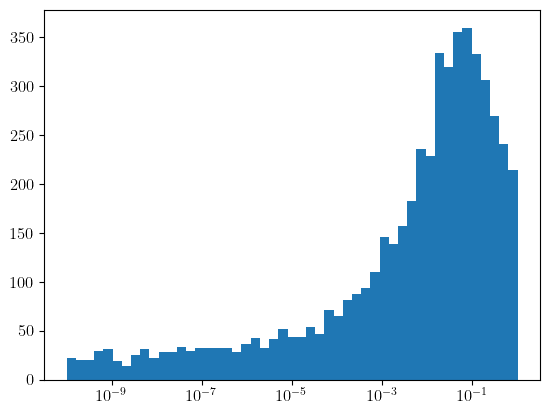

In [11]:
fig, ax = plt.subplots()
bins = np.logspace(-10, 0, 50)
ax.hist(weights, bins=bins)
ax.set_xscale('log')

In [12]:
colors = ["#cccccc", '#BF0001']
pqcd_cmap = LinearSegmentedColormap.from_list("gray_to_red", colors)

In [13]:
def rescale(weight, vmin=1e-5):
    if weight < vmin:
        return 0
    else:
        log_weight = np.log10(weight)
        return (log_weight-np.log10(vmin))/(0-np.log10(vmin))

In [14]:
rescale(1), rescale(1e-4), rescale(1e-5), rescale(1e-6)

(np.float64(1.0), np.float64(0.2), np.float64(0.0), 0)

Plot the EOS extensions colored by their weight:

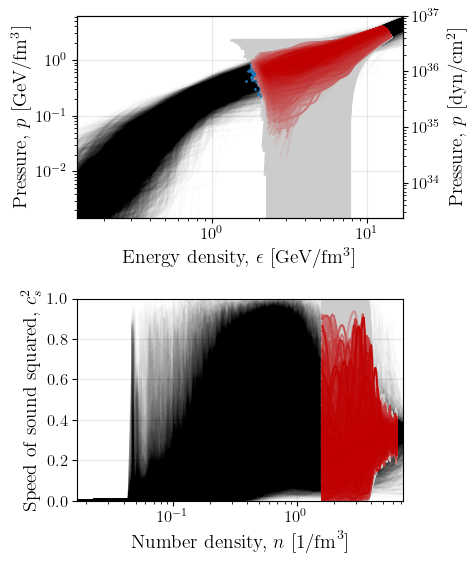

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(4.2, 6.3))
fig.subplots_adjust(hspace=0.4)

for ax in axs:
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3)

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')

# ---

for i, n in enumerate(collated_eos_gp2.eos.iloc[l_gp2:l_gp2+number_gp2]):

    df = pd.read_csv(
        f'../data/eos-draws-modified/gp2/margagn/DRAWmod1000-{int(n)//1000:06}/eos-draw-{int(n):06}.csv'
    )

    pressure = to_GeV_per_cubic_femtometre(df.pressurec2)
    energy_density = to_GeV_per_cubic_femtometre(df.energy_densityc2)
    number_density = to_nucleons_per_cubic_femtometre(df.baryon_density)
    speed_of_sound_squared = np.gradient(pressure, energy_density)

    axs[0].plot(
        energy_density,
        pressure,
        c='k',
        alpha=0.01,
        zorder=1
    )

    axs[0].plot(e_kde[i], p_kde[i], 'o', c='C0', markersize=1, zorder=1.1)

    axs[1].plot(
        number_density,
        speed_of_sound_squared,
        c='k',
        alpha=0.01,
        zorder=1
    )

for index, eos in eos_extensions.iterrows():
    mask = eos.n > n0
    weight = weights[index]
    c = pqcd_cmap(rescale(weight))
    axs[0].plot(eos.e[mask], eos.p[mask], c=c, zorder=weight+1.2)
    speed_of_sound_squared = np.gradient(eos.p, eos.e)
    axs[1].plot(eos.n[mask], speed_of_sound_squared[mask], c=c, zorder=weight+1.2)

# ---

axs[0].set_xlim(xlim_pe)
axs[0].set_ylim(ylim_pe)

axs[1].set_xlim(xlim_cn)
axs[1].set_ylim(ylim_cn)

# ---

twinx = axs[0].twinx()
twinx.set_yscale('log')
twinx.set_ylim(GeV_per_cubic_femtometer_to_dyn_per_square_cm(np.array(axs[0].get_ylim())))
twinx.set_ylabel(r'Pressure, $p\ [\mathrm{dyn}/\mathrm{cm}^2]$')

# ---

axs[0].set_xlabel(r'Energy density, $\epsilon$ [GeV/fm$^3$]')
axs[0].set_ylabel(r'Pressure, $p$ [GeV/fm$^3$]')

axs[1].set_xlabel(r'Number density, $n$ [$1/\mathrm{fm}^3$]')
axs[1].set_ylabel(r'Speed of sound squared, $c_s^2$');

To compare with the unified GP we will construct 90% credible interval quantiles for the EOS extensions, weighted by the abpve weights.

In [16]:
from scipy.interpolate import interp1d
from pqcd.utils import weighted_quantile

In [17]:
epsilon_regular = np.linspace(1, xlim_pe[1], 1000)

In [18]:
p_interp = []
cs2_arrays = []

for index, eos in eos_extensions.iterrows():
    p_interp.append(
        interp1d(
            eos.e,
            eos.p,
            bounds_error=False,
        )(epsilon_regular)
    )
    cs2 = np.gradient(eos.p, eos.e)
    cs2_arrays.append(cs2)


In [19]:
p_interp = np.array(p_interp)
cs2_arrays = np.array(cs2_arrays)

In [20]:
p_quantiles = []
cs2_quantiles = []
for i in range(len(epsilon_regular)):
    p_quantiles.append(weighted_quantile(p_interp[:, i], [0.05, 0.5, 0.95], weights))
for i in range(len(eos_extensions.n[0])):
    cs2_quantiles.append(weighted_quantile(cs2_arrays[:, i], [0.05, 0.5, 0.95], weights))

In [21]:
p_quantiles = np.array(p_quantiles).T
cs2_quantiles = np.array(cs2_quantiles).T

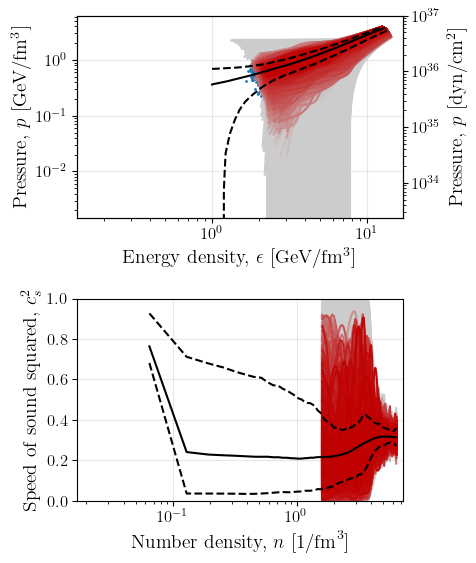

In [22]:
fig, axs = plt.subplots(2, 1, figsize=(4.2, 6.3))
fig.subplots_adjust(hspace=0.4)

for ax in axs:
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3)

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')

# ---

for i, n in enumerate(collated_eos_gp2.eos.iloc[l_gp2:l_gp2+number_gp2]):
    axs[0].plot(e_kde[i], p_kde[i], 'o', c='C0', markersize=1, zorder=1.1)

for index, eos in eos_extensions.iterrows():
    mask = eos.n > n0
    weight = weights[index]
    c = pqcd_cmap(rescale(weight))
    axs[0].plot(eos.e[mask], eos.p[mask], c=c, zorder=weight+1.2)
    speed_of_sound_squared = np.gradient(eos.p, eos.e)
    axs[1].plot(eos.n[mask], speed_of_sound_squared[mask], c=c, zorder=weight+1.2)

axs[0].plot(epsilon_regular, p_quantiles[0], 'k--', zorder=3)
axs[0].plot(epsilon_regular, p_quantiles[1], 'k-', zorder=3)
axs[0].plot(epsilon_regular, p_quantiles[2], 'k--', zorder=3)

axs[1].plot(eos_extensions.n[0], cs2_quantiles[0], 'k--', zorder=3)
axs[1].plot(eos_extensions.n[0], cs2_quantiles[1], 'k-', zorder=3)
axs[1].plot(eos_extensions.n[0], cs2_quantiles[2], 'k--', zorder=3)

# ---

axs[0].set_xlim(xlim_pe)
axs[0].set_ylim(ylim_pe)

axs[1].set_xlim(xlim_cn)
axs[1].set_ylim(ylim_cn)

# ---

twinx = axs[0].twinx()
twinx.set_yscale('log')
twinx.set_ylim(GeV_per_cubic_femtometer_to_dyn_per_square_cm(np.array(axs[0].get_ylim())))
twinx.set_ylabel(r'Pressure, $p\ [\mathrm{dyn}/\mathrm{cm}^2]$')

# ---

axs[0].set_xlabel(r'Energy density, $\epsilon$ [GeV/fm$^3$]')
axs[0].set_ylabel(r'Pressure, $p$ [GeV/fm$^3$]')

axs[1].set_xlabel(r'Number density, $n$ [$1/\mathrm{fm}^3$]')
axs[1].set_ylabel(r'Speed of sound squared, $c_s^2$');

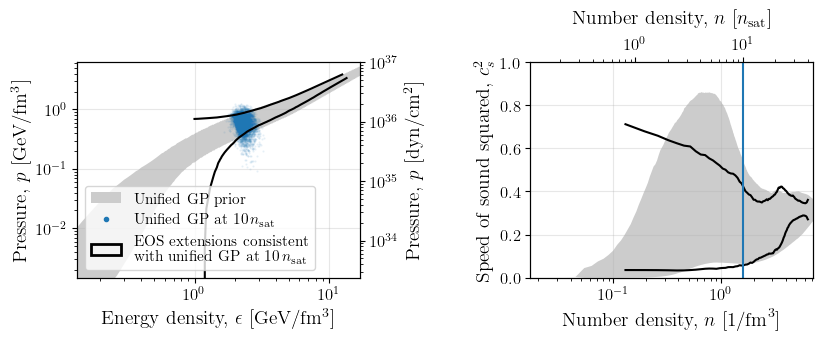

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(9.5, 2.8))
fig.subplots_adjust(wspace=0.6)

for ax in axs:
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3)

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')

# ---

prior_quantiles_pe = to_GeV_per_cubic_femtometre(
    pd.read_csv('../data/eos-draws-modified/gp2/quantiles/p_of_eps_quantiles_prior.csv')
)

axs[0].fill_between(
    x_pe,
    prior_quantiles_pe.loc[5,:].values,
    prior_quantiles_pe.loc[95,:].values,
    **prior_kwargs
)

# ---

prior_quantiles_cn = pd.read_csv(
    '../data/eos-draws-modified/gp2/quantiles/cs2_of_rho_quantiles_prior.csv'
)

axs[1].fill_between(
    x_cn,
    prior_quantiles_cn.loc[5,:].values,
    prior_quantiles_cn.loc[95,:].values,
    **prior_kwargs
)

# ---

for i, n in enumerate(collated_eos_gp2.eos.iloc[l_gp2:l_gp2+number_gp2]):
    axs[0].plot(e_kde[i], p_kde[i], '.', c='C0', alpha=0.1, markersize=1, zorder=1.1)

# axs[0].imshow(
#     np.rot90(Z), 
#     extent=[x_min, x_max, y_min, y_max], 
#     cmap=transparent_to_black,
#     aspect='auto',
#     zorder=1
# )

axs[1].axvline(n0)

# ---

lower_mask = epsilon_regular > 0 # 2.1
upper_mask = epsilon_regular > 0 # 2.5

axs[0].plot(epsilon_regular[upper_mask], p_quantiles[0][upper_mask], 'k', zorder=1.3)
axs[0].plot(epsilon_regular[lower_mask], p_quantiles[2][lower_mask], 'k', zorder=1.3)

cs2_mask = eos_extensions.n[0][2:] > 0 # n0
axs[1].plot(eos_extensions.n[0][2:][cs2_mask], cs2_quantiles[0][2:][cs2_mask], 'k', zorder=1.3)
axs[1].plot(eos_extensions.n[0][2:][cs2_mask], cs2_quantiles[2][2:][cs2_mask], 'k', zorder=1.3)

# ---

axs[0].set_xlim(xlim_pe)
axs[0].set_ylim(ylim_pe)

axs[1].set_xlim(xlim_cn)
axs[1].set_ylim(ylim_cn)

# ---

twinx = axs[0].twinx()
twinx.set_yscale('log')
twinx.set_ylim(GeV_per_cubic_femtometer_to_dyn_per_square_cm(np.array(axs[0].get_ylim())))
twinx.set_ylabel(r'Pressure, $p\ [\mathrm{dyn}/\mathrm{cm}^2]$')

twiny = axs[1].twiny()
twiny.set_xscale('log')
twiny.set_xlim(np.array(axs[1].get_xlim())/nsat)
twiny.set_xlabel(r'Number density, $n$ [$n_\mathrm{sat}$]', labelpad=10)

# ---

custom_handles = [
    mpatches.Patch(**prior_kwargs),
    plt.Line2D([0], [0], color='C0', lw=0, marker='.'),
    mpatches.Patch(fill=None, edgecolor='k', lw=2),
]
custom_labels = [
    'Unified GP prior',
    r'Unified GP at $10\,n_\mathrm{sat}$',
    'EOS extensions consistent\n' r'with unified GP at $10\,n_\mathrm{sat}$'
]
axs[0].legend(custom_handles, custom_labels, loc='lower left', fontsize=11)

# ---

axs[0].set_xlabel(r'Energy density, $\epsilon$ [GeV/fm$^3$]')
axs[0].set_ylabel(r'Pressure, $p$ [GeV/fm$^3$]')

axs[1].set_xlabel(r'Number density, $n$ [$1/\mathrm{fm}^3$]')
axs[1].set_ylabel(r'Speed of sound squared, $c_s^2$')

fig.savefig('figures/flexibility_comparison.pdf', bbox_inches='tight')